<h2 style="color:green" align="center"> Linear Regression Multiple Variables</h2>

In [ ]:

import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Daily_Demand_Forecasting_Orders.csv',delimiter=';')
df.head(2)

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
0,1,4,316.307,223.270,61.543,175.586,302.448,0.0,65556,44914,188411,14793,539.577
1,1,5,128.633,96.042,38.058,56.037,130.580,0.0,40419,21399,89461,7679,224.675


In [ ]:
df.describe()

,"Week of the month (first week, second, third, fourth or fifth week",Day of the week (Monday to Friday),Non-urgent order,Urgent order,Order type A,Order type B,Order type C,Fiscal sector orders,Orders from the traffic controller sector,Banking orders (1),Banking orders (2),Banking orders (3),Target (Total orders)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,3.016667,4.033333,172.554933,118.920850,52.112217,109.229850,139.531250,77.396133,44504.350000,46640.833333,79401.483333,23114.633333,300.873317
std,1.282102,1.401775,69.505788,27.170929,18.829911,50.741388,41.442932,186.502470,12197.905134,45220.736293,40504.420041,13148.039829,89.602041
min,1.000000,2.000000,43.651000,77.371000,21.826000,25.125000,74.372000,0.000000,11992.000000,3452.000000,16411.000000,7679.000000,129.412000
25%,2.000000,3.000000,125.348000,100.888000,39.456250,74.916250,113.632250,1.243250,34994.250000,20130.000000,50680.500000,12609.750000,238.195500
50%,3.000000,4.000000,151.062500,113.114500,47.166500,99.482000,127.990000,7.831500,44312.000000,32527.500000,67181.000000,18011.500000,288.034500
75%,4.000000,5.000000,194.606500,132.108250,58.463750,132.171000,160.107500,20.360750,52111.750000,45118.750000,94787.750000,31047.750000,334.237250
max,5.000000,6.000000,435.304000,223.270000,118.178000,267.342000,302.448000,865.000000,71772.000000,210508.000000,188411.000000,73839.000000,616.453000


In [ ]:
print(df.columns)


Index(['Week of the month (first week, second, third, fourth or fifth week',
       'Day of the week (Monday to Friday)', 'Non-urgent order',
       'Urgent order', 'Order type A', 'Order type B', 'Order type C',
       'Fiscal sector orders', 'Orders from the traffic controller sector',
       'Banking orders (1)', 'Banking orders (2)', 'Banking orders (3)',
       'Target (Total orders)'],
      dtype='str')


In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)

print(df.columns)


Index(['Week of the month first week, second, third, fourth or fifth week',
       'Day of the week Monday to Friday', 'Non-urgent order', 'Urgent order',
       'Order type A', 'Order type B', 'Order type C', 'Fiscal sector orders',
       'Orders from the traffic controller sector', 'Banking orders 1',
       'Banking orders 2', 'Banking orders 3', 'Target Total orders'],
      dtype='str')


In [ ]:
X = df[[
    "Week of the month first week, second, third, fourth or fifth week",
    "Day of the week Monday to Friday",
    "Non-urgent order",
    "Urgent order",
    'Order type A', 'Order type B',  'Fiscal sector orders',
       'Orders from the traffic controller sector', 'Banking orders 1',
       'Banking orders 2', 'Banking orders 3'
]]

y = df["Target Total orders"]



In [ ]:
X.shape

(60, 11)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
X_train.shape

(48, 11)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 :", r2)


MAE: 15.402378887327123
MSE: 877.3645058389108
R2 : 0.9142813054197058


In [ ]:
import numpy as np
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 29.62033939439099


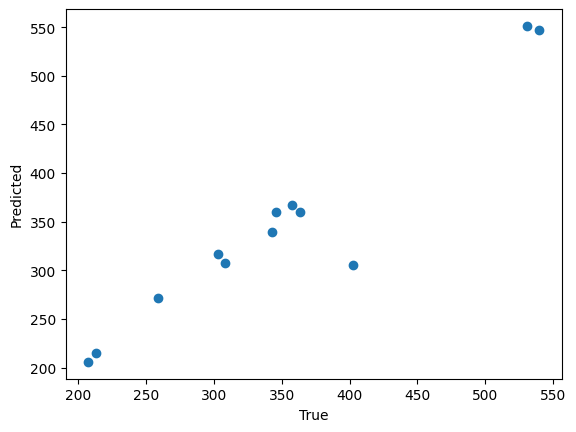

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()


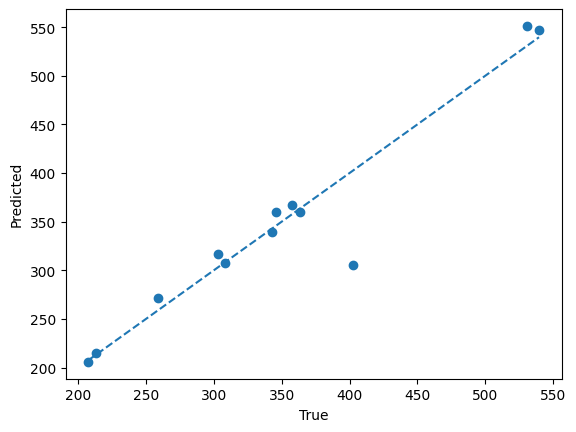

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()


In [ ]:
residuals = np.abs(y_test - y_pred)

worst_idx = residuals.idxmax()

print("Worst index:", worst_idx)
print("True value:", y_test.loc[worst_idx])
print("Predicted:", y_pred[list(y_test.index).index(worst_idx)])


Worst index: 48
True value: 402.607
Predicted: 305.6463731532256


In [ ]:
df.loc[worst_idx]


Week of the month first week, second, third, fourth or fifth week        3.000
Day of the week Monday to Friday                                         5.000
Non-urgent order                                                       120.629
Urgent order                                                           112.703
Order type A                                                            39.600
Order type B                                                           240.922
Order type C                                                           122.085
Fiscal sector orders                                                   169.275
Orders from the traffic controller sector                            37387.000
Banking orders 1                                                     20246.000
Banking orders 2                                                     63778.000
Banking orders 3                                                     13886.000
Target Total orders                                 